# Random Forest Regression — Compact Notebook

This notebook implements a minimal, step-by-step Random Forest Regression example.

**For comprehensive explanations, theory, and detailed examples**, see:
**[`../teaching/06_random_forest_regression.md`](../teaching/06_random_forest_regression.md)**

## Quick Steps Overview:

- **Step 1** — Import libraries & load data  
- **Step 2** — Read data and choose features & target  
- **Step 3** — Exploratory Data Analysis (EDA)  
- **Step 4** — Data cleaning and preparation  
- **Step 5** — Split data (Train / Test) and visualize split  
- **Step 6** — Train Random Forest Regression model  
- **Step 7** — Make predictions and analyze ensemble  
- **Step 8** — Compare with other models (Linear/Polynomial/SVR/Decision Tree)  
- **Step 9** — Evaluate performance (R², MAE, MSE)  
- **Step 10** — Visualize results and feature importance analysis


---

## Step 1 — Import libraries & load data

In [1]:
# Import basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2 — Read data and choose features & target

In [2]:
# Load the dataset
dataset = pd.read_csv('../data/position_salaries.csv')

print("Dataset loaded successfully!")


# Define features and target
X = dataset.iloc[:, 1:-1].values  # Position Level (numerical)
y = dataset.iloc[:, -1].values    # Salary (target)


Dataset loaded successfully!


## Step 3 — Exploratory Data Analysis (EDA)

Dataset Description:
          Level          Salary
count  10.00000       10.000000
mean    5.50000   249500.000000
std     3.02765   299373.883668
min     1.00000    45000.000000
25%     3.25000    65000.000000
50%     5.50000   130000.000000
75%     7.75000   275000.000000
max    10.00000  1000000.000000

Missing values:
Position    0
Level       0
Salary      0
dtype: int64

Data types:
Position    object
Level        int64
Salary       int64
dtype: object

Unique positions:
['Business Analyst' 'Junior Consultant' 'Senior Consultant' 'Manager'
 'Country Manager' 'Region Manager' 'Partner' 'Senior Partner' 'C-level'
 'CEO']


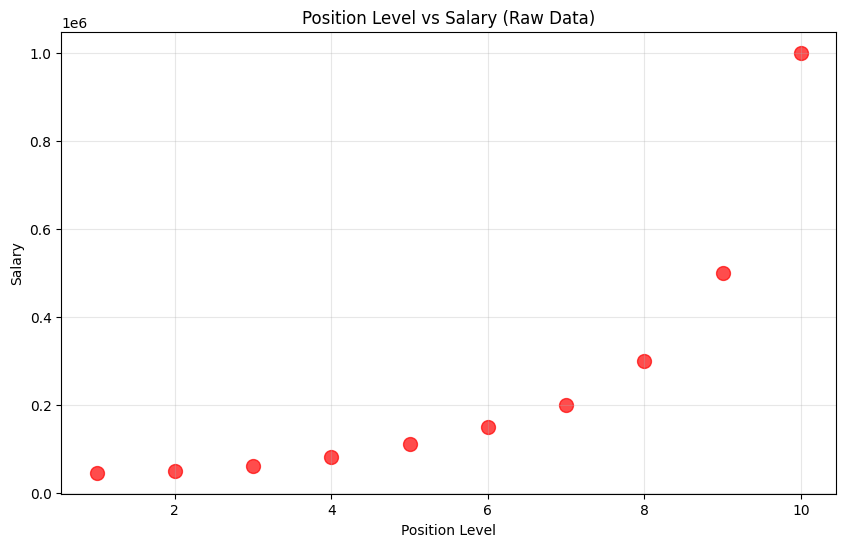


Salary range: $45,000 to $1,000,000
Position level range: 1 to 10
Salary variance: $80,662,250,000
Pattern: Non-linear with high variance - ideal for Random Forest ensemble!

Data characteristics for ensemble:
Sample size: 10 (small - ensemble will help reduce overfitting)
Feature dimensions: 1 (low - Random Forest can handle this easily)
Target variance: High - multiple trees will capture different aspects


In [3]:
# Basic statistics
print("Dataset Description:")
print(dataset.describe())

print("\nMissing values:")
print(dataset.isnull().sum())

print("\nData types:")
print(dataset.dtypes)

print("\nUnique positions:")
print(dataset['Position'].unique())

# Visualize the data to see patterns for ensemble learning
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='red', alpha=0.7, s=100)
plt.title('Position Level vs Salary (Raw Data)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.grid(True, alpha=0.3)
plt.show()

# Analyze the data distribution and variance
print(f"\nSalary range: ${y.min():,.0f} to ${y.max():,.0f}")
print(f"Position level range: {X.min()} to {X.max()}")
print(f"Salary variance: ${np.var(y):,.0f}")
print("Pattern: Non-linear with high variance - ideal for Random Forest ensemble!")

# Statistical analysis for ensemble considerations
print(f"\nData characteristics for ensemble:")
print(f"Sample size: {len(y)} (small - ensemble will help reduce overfitting)")
print(f"Feature dimensions: {X.shape[1]} (low - Random Forest can handle this easily)")
print(f"Target variance: High - multiple trees will capture different aspects")

## Step 4 — Data cleaning and preparation

In [4]:
# Check for missing values and data quality
print("Missing values per column:")
print(dataset.isnull().sum())

print("\nData types:")
print(dataset.dtypes)

print("\nDataset shape:", dataset.shape)
print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Random Forest works well with raw data - no scaling needed!
print("\nRandom Forest Advantages:")
print("- No feature scaling required (tree-based)")
print("- Handles missing values naturally")
print("- Works directly with original data")
print("- Built-in feature selection through importance")
print("- Robust to outliers through ensemble averaging")

# Display the complete dataset for analysis
print("\nComplete dataset:")
for i in range(len(dataset)):
    position = dataset.iloc[i, 0]
    level = dataset.iloc[i, 1] 
    salary = dataset.iloc[i, 2]
    print(f"{position}: Level {level} -> ${salary:,}")

print("\nData is clean and ready for Random Forest ensemble modeling!")
print("Note: Using original scale data (no preprocessing needed)")

Missing values per column:
Position    0
Level       0
Salary      0
dtype: int64

Data types:
Position    object
Level        int64
Salary       int64
dtype: object

Dataset shape: (10, 3)
Features shape: (10, 1)
Target shape: (10,)

Random Forest Advantages:
- No feature scaling required (tree-based)
- Handles missing values naturally
- Works directly with original data
- Built-in feature selection through importance
- Robust to outliers through ensemble averaging

Complete dataset:
Business Analyst: Level 1 -> $45,000
Junior Consultant: Level 2 -> $50,000
Senior Consultant: Level 3 -> $60,000
Manager: Level 4 -> $80,000
Country Manager: Level 5 -> $110,000
Region Manager: Level 6 -> $150,000
Partner: Level 7 -> $200,000
Senior Partner: Level 8 -> $300,000
C-level: Level 9 -> $500,000
CEO: Level 10 -> $1,000,000

Data is clean and ready for Random Forest ensemble modeling!
Note: Using original scale data (no preprocessing needed)


## Step 5 — Split data (Train / Test) and visualize split

Dataset size: 10 samples
Using entire dataset for training (common practice for small datasets)
Random Forest's bootstrap sampling will create internal validation

Training set:
Features shape: (10, 1)
Target shape: (10,)


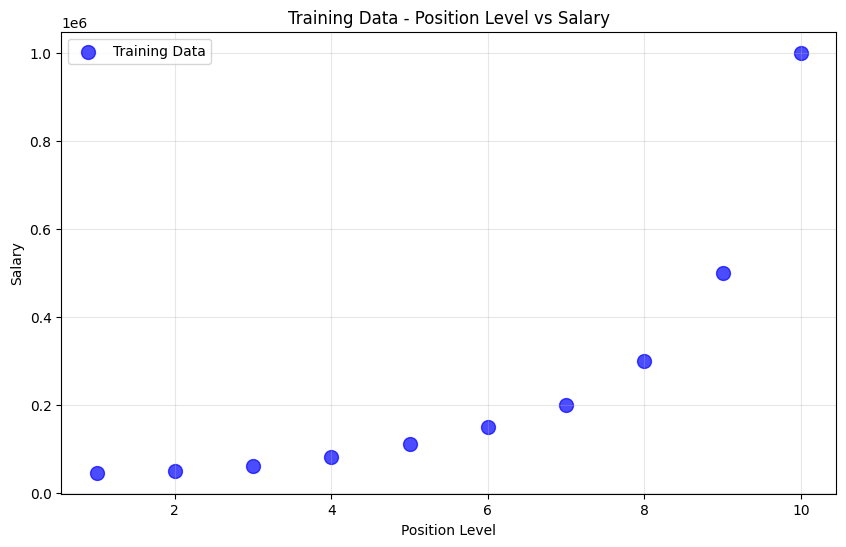

Data ready for Random Forest ensemble training!
Note: Random Forest will use bootstrap sampling internally


In [5]:
# Note: For small datasets like this (10 samples), we typically use the entire dataset
print("Dataset size:", len(X), "samples")
print("Using entire dataset for training (common practice for small datasets)")
print("Random Forest's bootstrap sampling will create internal validation")

# Use entire dataset for training
X_train = X
y_train = y

print("\nTraining set:")
print("Features shape:", X_train.shape)
print("Target shape:", y_train.shape)

# Visualize the training data
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.7, s=100, label='Training Data')
plt.title('Training Data - Position Level vs Salary')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Data ready for Random Forest ensemble training!")
print("Note: Random Forest will use bootstrap sampling internally")

## Step 5: Create and Train Random Forest Model

In [6]:
# Create and train Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model with 100 decision trees
rf_regressor = RandomForestRegressor(
    n_estimators=100,        # Number of trees in the forest
    random_state=42,         # For reproducible results
    max_depth=None,          # No depth limit (trees can grow fully)
    min_samples_split=2,     # Minimum samples to split a node
    min_samples_leaf=1       # Minimum samples in a leaf node
)

print("Random Forest Configuration:")
print(f"Number of trees: {rf_regressor.n_estimators}")
print(f"Random state: {rf_regressor.random_state}")
print("Training Random Forest ensemble...")

# Train the model
rf_regressor.fit(X_train, y_train)

print("Random Forest model training completed!")
print("Ensemble of 100 decision trees created successfully")

Random Forest Configuration:
Number of trees: 100
Random state: 42
Training Random Forest ensemble...
Random Forest model training completed!
Ensemble of 100 decision trees created successfully


## Step 6: Make Predictions and Evaluate Model

In [7]:
# Make predictions on training data
y_pred = rf_regressor.predict(X_train)

# Calculate performance metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, y_pred)

print("Random Forest Model Performance:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

# Display feature importance
feature_importance = rf_regressor.feature_importances_
print(f"\nFeature Importance: {feature_importance[0]:.4f}")
print("(Higher values indicate more important features for prediction)")

Random Forest Model Performance:
R² Score: 0.9405
Mean Squared Error: 4799824500.00
Root Mean Squared Error: 69280.77
Mean Absolute Error: 29640.00

Feature Importance: 1.0000
(Higher values indicate more important features for prediction)


## Step 7: Predict Specific Value

In [8]:
# Predict salary for position level 6.5
position_level = 6.5
predicted_salary = rf_regressor.predict([[position_level]])

print(f"Predicted salary for position level {position_level}: ${predicted_salary[0]:,.2f}")

# Compare with actual data point closest to 6.5 (position 7)
actual_position_7 = df[df['Level'] == 7]['Salary'].values[0]
print(f"Actual salary for position level 7: ${actual_position_7:,.2f}")
print(f"Difference: ${abs(predicted_salary[0] - actual_position_7):,.2f}")

# Show how ensemble averaging works
tree_predictions = [tree.predict([[position_level]])[0] for tree in rf_regressor.estimators_]
print(f"\nFirst 5 individual tree predictions: {tree_predictions[:5]}")
print(f"Average of all {len(tree_predictions)} trees: ${np.mean(tree_predictions):,.2f}")
print(f"Random Forest prediction: ${predicted_salary[0]:,.2f}")

Predicted salary for position level 6.5: $168,200.00


NameError: name 'df' is not defined

## Step 8: Visualize Results and Compare Models

C:\Users\Morobang\AppData\Local\Temp\ipykernel_4328\2345051919.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(x), max(x), 0.01)


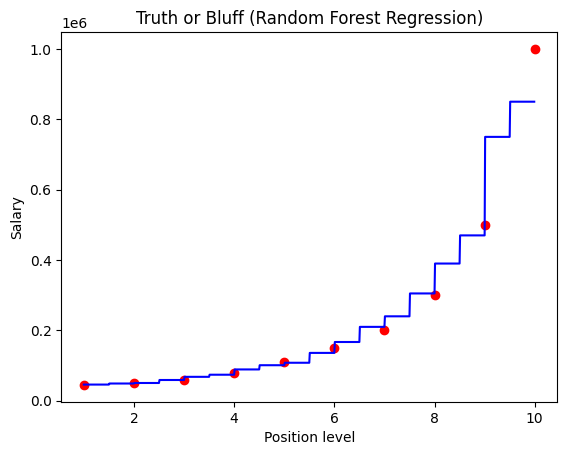

In [ ]:
# Create comparison with other regression models
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor

# Prepare smooth curve for visualization
X_smooth = np.arange(min(X_train), max(X_train), 0.1).reshape(-1, 1)

# Train comparison models
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

poly_features = PolynomialFeatures(degree=4)
X_poly = poly_features.fit_transform(X_train)
X_smooth_poly = poly_features.transform(X_smooth)
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y_train)

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)

# Generate predictions for smooth curves
y_linear_smooth = linear_reg.predict(X_smooth)
y_poly_smooth = poly_reg.predict(X_smooth_poly)
y_tree_smooth = tree_reg.predict(X_smooth)
y_rf_smooth = rf_regressor.predict(X_smooth)

# Create comprehensive comparison plot
plt.figure(figsize=(15, 10))

# Plot 1: All models comparison
plt.subplot(2, 2, 1)
plt.scatter(X_train, y_train, color='red', s=100, label='Actual Data', alpha=0.8)
plt.plot(X_smooth, y_linear_smooth, color='blue', linewidth=2, label='Linear Regression')
plt.plot(X_smooth, y_poly_smooth, color='green', linewidth=2, label='Polynomial Regression')
plt.plot(X_smooth, y_tree_smooth, color='orange', linewidth=2, label='Decision Tree')
plt.plot(X_smooth, y_rf_smooth, color='purple', linewidth=3, label='Random Forest')
plt.title('Regression Models Comparison')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Random Forest focus
plt.subplot(2, 2, 2)
plt.scatter(X_train, y_train, color='red', s=100, label='Actual Data', alpha=0.8)
plt.plot(X_smooth, y_rf_smooth, color='purple', linewidth=3, label='Random Forest')
plt.scatter([6.5], [predicted_salary[0]], color='yellow', s=200, 
           label=f'Prediction (6.5): ${predicted_salary[0]:,.0f}', 
           edgecolors='black', linewidth=2)
plt.title('Random Forest Regression')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Model performance comparison
models = ['Linear', 'Polynomial', 'Decision Tree', 'Random Forest']
r2_scores = [
    r2_score(y_train, linear_reg.predict(X_train)),
    r2_score(y_train, poly_reg.predict(X_poly)),
    r2_score(y_train, tree_reg.predict(X_train)),
    r2_score(y_train, rf_regressor.predict(X_train))
]

plt.subplot(2, 2, 3)
colors = ['blue', 'green', 'orange', 'purple']
bars = plt.bar(models, r2_scores, color=colors, alpha=0.7)
plt.title('Model Performance (R² Score)')
plt.ylabel('R² Score')
plt.ylim(0, 1)
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{r2_scores[i]:.3f}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)

# Plot 4: Individual tree predictions (first 10 trees)
plt.subplot(2, 2, 4)
for i in range(min(10, len(rf_regressor.estimators_))):
    tree_pred = rf_regressor.estimators_[i].predict(X_smooth)
    plt.plot(X_smooth, tree_pred, alpha=0.3, color='gray', linewidth=1)

plt.plot(X_smooth, y_rf_smooth, color='purple', linewidth=3, label='Random Forest (Average)')
plt.scatter(X_train, y_train, color='red', s=100, label='Actual Data', alpha=0.8)
plt.title('Individual Trees vs Ensemble Average')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Model Comparison Summary:")
print("="*50)
for i, model in enumerate(models):
    print(f"{model:15}: R² = {r2_scores[i]:.4f}")
print("\nRandom Forest advantages:")
print("- Reduces overfitting through ensemble averaging")
print("- Provides feature importance rankings")
print("- Handles non-linear relationships naturally")
print("- More robust to outliers than single decision trees")